In [2]:
source("src/functions_and_things.r")

load_libraries()

In [21]:
df_daily <- read.csv("data/daily_ridership.csv")
head(df_daily)

,date,borough,ridership
,<chr>,<chr>,<int>
1,2024-06-03,Bronx,81362
2,2024-06-03,Brooklyn,262036
3,2024-06-03,Manhattan,316780
4,2024-06-03,Queens,174702
5,2024-06-04,Bronx,84976
6,2024-06-04,Brooklyn,284948


In [22]:
df_weekly <- read.csv("data/combined_data_weekly.csv")
head(df_weekly)

,date,borough,ridership,week
,<chr>,<chr>,<int>,<chr>
1,2024-06-03,Bronx,81362,2024-06-02
2,2024-06-03,Brooklyn,262036,2024-06-02
3,2024-06-03,Manhattan,316780,2024-06-02
4,2024-06-03,Queens,174702,2024-06-02
5,2024-06-04,Bronx,84976,2024-06-02
6,2024-06-04,Brooklyn,284948,2024-06-02


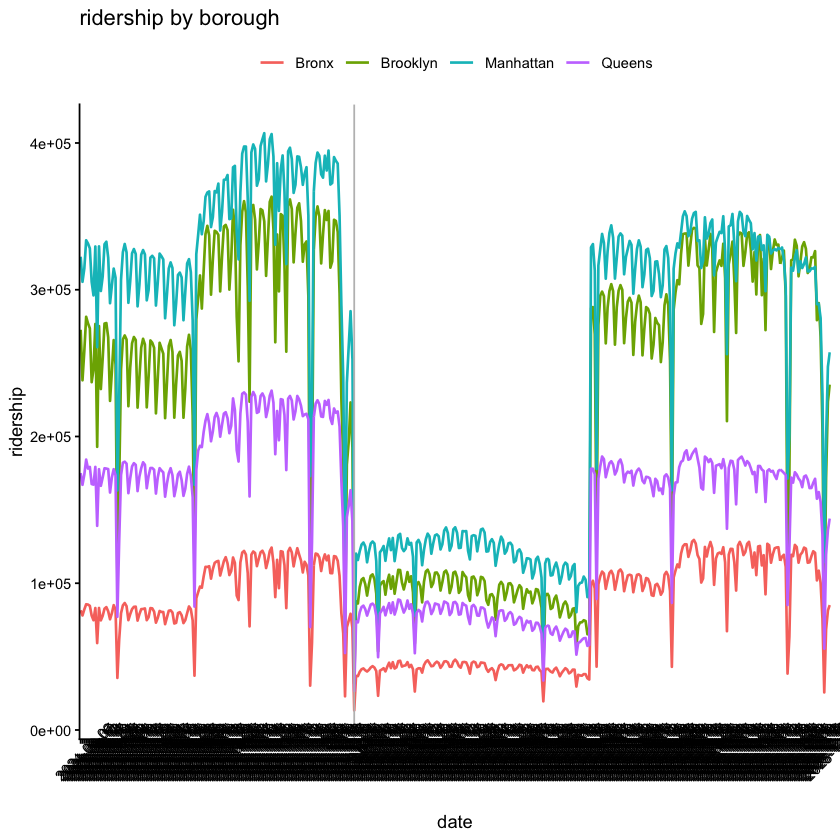

In [24]:
df_daily |> filter(date > "2024-06-05" & date < "2025-12-31") |> 
ggplot(aes(x = date, y = ridership, group = borough, color = as.factor((borough)))) + 
    geom_line(lwd = .75) + theme_classic() +
    theme(legend.position= "top",
          legend.title = element_blank(),
          axis.text.x = element_text(angle = 45)) + 
    geom_vline(xintercept = "2025-01-01", color = "grey") + 
    labs(title = "ridership by borough")

In [18]:
df_weekly %>%
  count(borough, week) %>%
  filter(n > 1)

borough,week,n
<chr>,<chr>,<int>
Bronx,2024-06-02,5
Bronx,2024-06-09,5
Bronx,2024-06-16,5
Bronx,2024-06-23,5
Bronx,2024-06-30,5
Bronx,2024-07-07,5
Bronx,2024-07-14,5
Bronx,2024-07-21,5
Bronx,2024-07-28,5


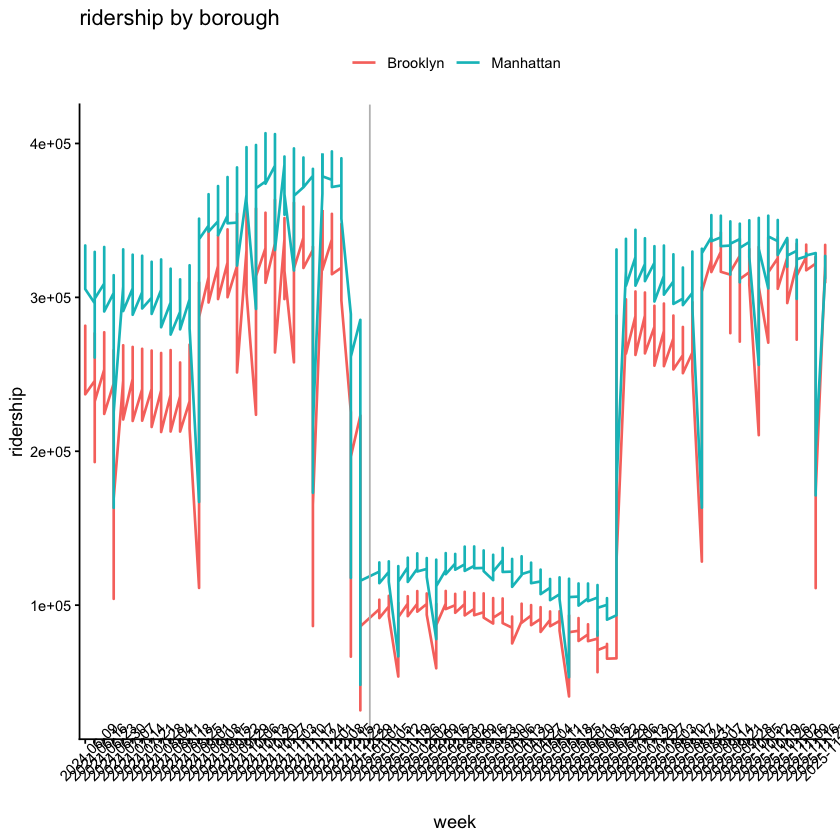

In [11]:
df_weekly |> filter(week > "2024-06-05" & week < "2025-12-04") |>
      filter(borough == "Brooklyn" | borough == "Manhattan") |> 
ggplot(aes(x = week, y = ridership, group = borough, color = as.factor((borough)))) + 
    geom_line(lwd = .75) + theme_classic() +
    theme(legend.position= "top",
          legend.title = element_blank(),
          axis.text.x = element_text(angle = 45)) + 
    geom_vline(xintercept = "2025-01-01", color = "grey") + 
    labs(title = "ridership by borough")

## Differince in Diff

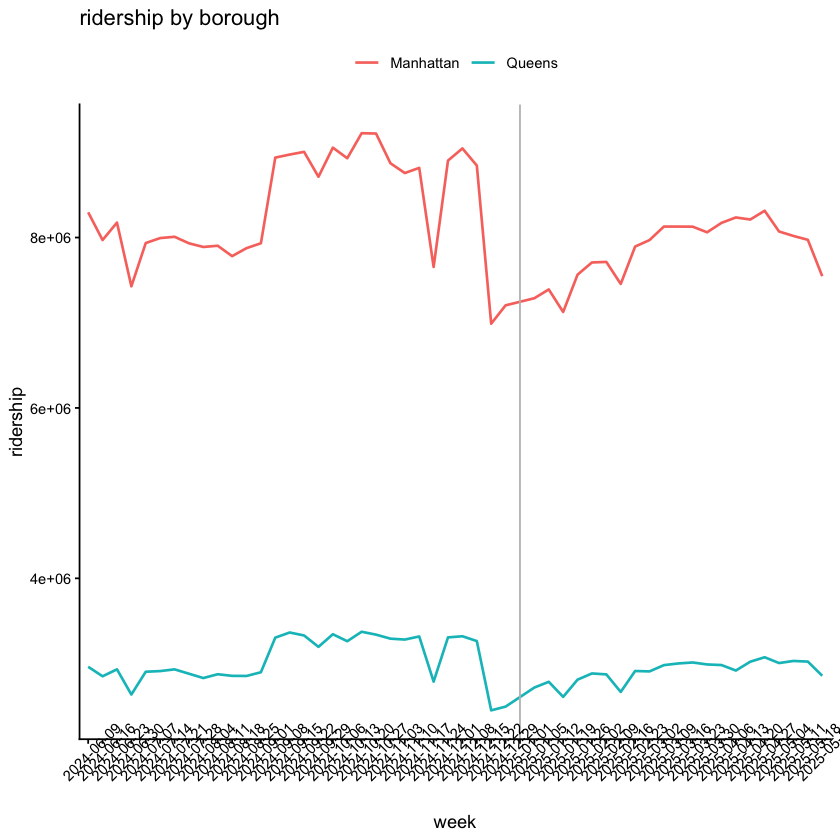

In [155]:
df |> filter(week > "2024-06-05" & week < "2025-05-29") |> 
      filter(borough == "Manhattan" | borough == "Queens") |>
ggplot(aes(x = week, y = ridership, group = borough, color = as.factor((borough)))) + 
    geom_line(lwd = .75) + theme_classic() +
    theme(legend.position= "top",
          legend.title = element_blank(),
          axis.text.x = element_text(angle = 45)) + 
    geom_vline(xintercept = "2025-01-01", color = "grey") + 
    labs(title = "ridership by borough")

### 18.2.1 - two way fixed effects

$$Y = \alpha_g + \alpha_t + \beta_1\text{Treated} + \epsilon$$

where 

$$
\begin{align*}
    Y &= ridership \\
    \alpha_g &= \text{treated or untreated}  \\
    \alpha_t &= \text{time period (treatment or not, post 2025)} \\
    \text{Treated} &= \text{binary variable, 1 if Manhattan after 2025}
\end{align*}
$$

"Two way fixed effects difference in differences estimator"

In [144]:
# treatment variable
df_daily |>
    mutate(
        date    = as.Date(date),
        Treated = (borough == "Manhattan") & (date > "2025-01-01")) -> df_daily

In [145]:
df_daily |> filter(borough == "Manhattan" | borough == "Queens") -> df_daily_group

tail(df_daily_group)

,date,borough,coords_cbd,ridership,Treated
,<date>,<chr>,<lgl>,<int>,<lgl>
1093,2025-05-31,Manhattan,FALSE,403219,TRUE
1094,2025-05-31,Manhattan,TRUE,524620,TRUE
1095,2025-05-31,Queens,FALSE,343241,FALSE
1096,2025-06-01,Manhattan,FALSE,5363,TRUE
1097,2025-06-01,Manhattan,TRUE,19374,TRUE
1098,2025-06-01,Queens,FALSE,3608,FALSE


In [146]:
check <- (df_daily$borough == "Manhattan" & df_daily$Treated == "FALSE")
sum(check)

[1] 430

In [147]:
# foels 
clfe <- feols(ridership ~ Treated | borough + date, data = df_daily_group)

msummary(clfe, stars = c('*' = .1, '**' = .05, '***' = .01))


+----------------+-------------+
|                | (1)         |
+================+=============+
| TreatedTRUE    | -16030.587  |
+----------------+-------------+
|                | (10765.785) |
+----------------+-------------+
| Num.Obs.       | 1098        |
+----------------+-------------+
| R2             | 0.773       |
+----------------+-------------+
| R2 Adj.        | 0.658       |
+----------------+-------------+
| R2 Within      | 0.003       |
+----------------+-------------+
| R2 Within Adj. | 0.002       |
+----------------+-------------+
| AIC            | 28271.4     |
+----------------+-------------+
| BIC            | 30111.8     |
+----------------+-------------+
| RMSE           | 67503.69    |
+----------------+-------------+
| FE: borough    | X           |
+----------------+-------------+
| FE: date       | X           |
+================+=============+
| * p < 0.1, ** p < 0.05, ***  |
| p < 0.01                     |
+================+=============+ 

`geom_smooth()` using formula = 'y ~ x'


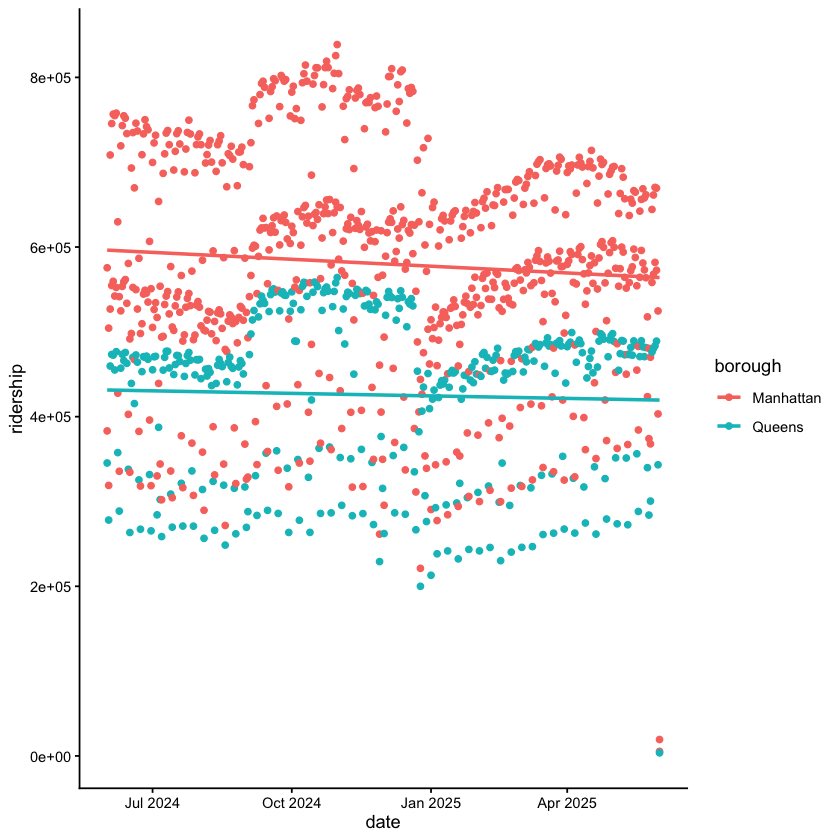

In [148]:
ggplot(data = df_daily_group, aes(x = date, y = ridership, color = borough)) + 
    geom_point() + theme_classic() + geom_smooth(method = "lm", se = FALSE)

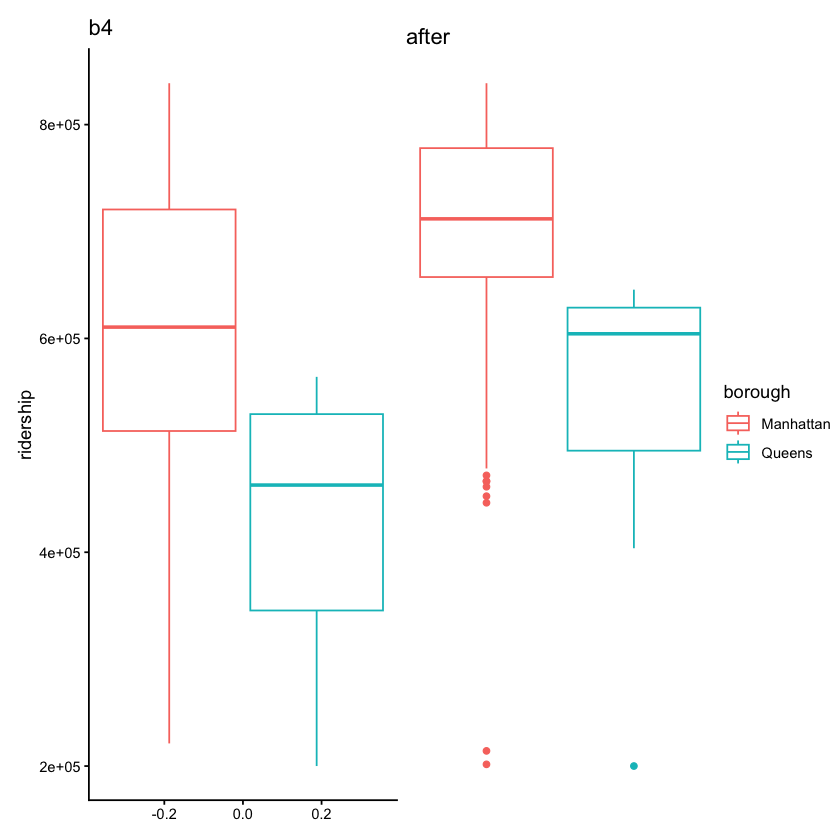

In [149]:
df_daily_group |> filter(date < "2025-01-01") |> 
ggplot(aes(y = ridership, color = borough)) + 
    geom_boxplot() + theme_classic() +
    theme(legend.position = "none") + labs(title = "b4")-> before

df_daily_group |> filter(date > "2025-01-01") |> 
ggplot(aes(y = ridership, color = borough)) + 
    geom_boxplot() + theme_void() + 
    labs(title = "after") -> after

before + after

### 18.2.3 supporting parallel trends?


$$Y = \alpha_g + \beta_1 Time + \beta_2 Time * Group + \epsilon$$

Are the trends different?

In [150]:
p_reg <- lm(ridership ~ date + date:borough, data = df_daily_group)

summary(p_reg)


Call:
lm(formula = ridership ~ date + date:borough, data = df_daily_group)

Residuals:
    Min      1Q  Median      3Q     Max 
-562519  -74396   22719   83333  256496 

Coefficients:
                     Estimate Std. Error t value Pr(>|t|)    
(Intercept)         1.931e+06  6.950e+05   2.778  0.00556 ** 
date               -6.733e+01  3.465e+01  -1.943  0.05226 .  
date:boroughQueens -7.711e+00  3.872e-01 -19.915  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 121300 on 1095 degrees of freedom
Multiple R-squared:  0.2679,	Adjusted R-squared:  0.2666 
F-statistic: 200.3 on 2 and 1095 DF,  p-value: < 2.2e-16


## Placebo (fake treatment)

In [157]:
fake = "2024-9-01"

df_daily_group |> mutate(Treated_fake = (borough == "Manhattan") & (date > fake)) -> df_daily_group 

tail(df_daily_group)

,date,borough,coords_cbd,ridership,Treated,Treated_fake
,<date>,<chr>,<lgl>,<int>,<lgl>,<lgl>
1093,2025-05-31,Manhattan,FALSE,403219,TRUE,TRUE
1094,2025-05-31,Manhattan,TRUE,524620,TRUE,TRUE
1095,2025-05-31,Queens,FALSE,343241,FALSE,FALSE
1096,2025-06-01,Manhattan,FALSE,5363,TRUE,TRUE
1097,2025-06-01,Manhattan,TRUE,19374,TRUE,TRUE
1098,2025-06-01,Queens,FALSE,3608,FALSE,FALSE


In [158]:
check2 <- (df_daily_group$borough == "Manhattan" & df_daily_group$Treated_fake == "FALSE")
sum(check2)

[1] 186

In [162]:
# foels fake

clfe_fake <- feols(ridership ~ Treated_fake | borough + date, data = df_daily_group)

msummary(list(clfe, clfe_fake), stars = c('*' = .1, '**' = .05, '***' = .01))


+------------------+-------------+-------------+
|                  | (1)         | (2)         |
+==================+=============+=============+
| TreatedTRUE      | -16030.587  |             |
+------------------+-------------+-------------+
|                  | (10765.785) |             |
+------------------+-------------+-------------+
| Treated_fakeTRUE |             | -3924.921   |
+------------------+-------------+-------------+
|                  |             | (12191.533) |
+------------------+-------------+-------------+
| Num.Obs.         | 1098        | 1098        |
+------------------+-------------+-------------+
| R2               | 0.773       | 0.772       |
+------------------+-------------+-------------+
| R2 Adj.          | 0.658       | 0.657       |
+------------------+-------------+-------------+
| R2 Within        | 0.003       | 0.000       |
+------------------+-------------+-------------+
| R2 Within Adj.   | 0.002       | -0.001      |
+------------------